In [318]:
# import
import polars as pl
import pyarrow as pa
import statsmodels.api as sm
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as mtrans
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as mtick
from matplotlib import cm
from matplotlib.patches import Patch
# for using Times New Roman
import matplotlib.font_manager
import os as os
import subprocess
import sys as sys
import re
import threading
import logging
import time
import math
import warnings
warnings.filterwarnings('ignore')

In [319]:
# Using seaborn's style
plt.style.use(['ggplot', 'seaborn-v0_8-whitegrid'])

WIDTH = 345

def set_size(width, fraction=1):
    """ Set aesthetic figure dimensions to avoid scaling in latex.

    Parameters
    ----------
    width: float
            Width in pts
    fraction: float
            Fraction of the width which you wish the figure to occupy

    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio

    fig_dim = (fig_width_in, fig_height_in)

    return fig_dim

config = {
    "figure.figsize": set_size(WIDTH),
    "grid.linestyle": '--',
#     "hatch.color": '#eeeeee',
    "hatch.color": 'grey',
    "hatch.linewidth": 0.618,
    # Use LaTeX to write all text
    "text.usetex": False,
    "font.family": "Times New Roman",
    #"text.latex.unicode": True,
    "axes.unicode_minus": True,
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 22,
    "font.size": 22,
    "legend.fontsize": 22,
    # Make the label fonts a little smaller
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.handletextpad": 0.5,
    "legend.columnspacing": 0.9,
    "legend.numpoints": 3,
}

mpl.rcParams.update(config)

### comparison plot function

In [323]:
def plot_latency_comparison(
    df,
    x_col='msg',
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured Latency', 'Predicted Latency'],
    markers=['o', '^'],
    colors=['#2980b9', '#e74c3c'],
    xlabel='Message Size (Bytes)',
    ylabel='Latency (ms)',  # Changed to ms
    pdf_filename='latency_comparison.pdf'
):
    
    df = df.filter(pl.col("msg") < 18874368)

    # Convert to log scale for better visualization
    df_pandas = df.to_pandas().sort_values(by=x_col)
    
    # Convert microseconds to milliseconds
    df_pandas_ms = df_pandas.copy()
    for col in y_cols:
        df_pandas_ms[col] = df_pandas[col] / 1000.0  # Convert us to ms

    dim = set_size(WIDTH, fraction=1)
    fig, axe = plt.subplots(figsize=dim, constrained_layout=True)

    # Plot both lines (using millisecond values)
    for y, label, marker, color in zip(y_cols, labels, markers, colors):
        axe.plot(df_pandas_ms[x_col], df_pandas_ms[y], 
                label=label, marker=marker, markersize=4, 
                color=color, linewidth=1)

    # Set log scale for x-axis
    axe.set_xscale('log', base=2)

    # Set y-axis to start from 0
    axe.set_ylim(bottom=0)
    
    # Grid and axes settings
    axe.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Create log2-based ticks
    x_ticks = [2**i for i in range(12, 25, 2)]  # Adjust range as needed
    x_labels = ["4K", "16K", "64K", "256K", "1M", "4M", "16M"]  # Separate strings with commas
    plt.xticks(x_ticks, labels=x_labels, rotation=15)

    axe.set_xlabel(xlabel)
    axe.set_ylabel(ylabel)

    # Legend
    axe.legend(
        loc='upper left',
        frameon=False,
        handletextpad=0.5,
        columnspacing=1,
        handlelength=1.5
    )

    # Save to PDF if filename is provided
    if pdf_filename:
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {pdf_filename}")

    plt.show()

In [325]:
def plot_BW_comparison(
    df,
    x_col='msg',
    y_cols=['BW (GB/s)', 'BW_pre (GB/s)'],
    labels=['Measured BW', 'Predicted BW'],
    markers=['o', '^'],
    colors=['#2980b9', '#e74c3c'],
    xlabel='Message Size (Bytes)',
    ylabel='Latency (ms)',  # Changed to ms
    pdf_filename='latency_comparison.pdf',
    protocol=None
):
    
    df = df.filter(pl.col("msg") > 16777216)

    # Convert to log scale for better visualization
    df_pandas = df.to_pandas().sort_values(by=x_col)
    
    # Convert microseconds to milliseconds
    df_pandas_ms = df_pandas.copy()
    for col in y_cols:
        df_pandas_ms[col] = df_pandas[col]

    dim = set_size(WIDTH, fraction=1)
    fig, axe = plt.subplots(figsize=dim, constrained_layout=True)

    # Plot both lines (using millisecond values)
    for y, label, marker, color in zip(y_cols, labels, markers, colors):
        axe.plot(df_pandas_ms[x_col], df_pandas_ms[y], 
                label=label, marker=marker, markersize=4, 
                color=color, linewidth=1)

    # Set log scale for x-axis
    axe.set_xscale('log', base=2)

    # Set y-axis to start from 0
    axe.set_ylim(bottom=0)
    
    # Grid and axes settings
    axe.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    if protocol == "LL":
        x_ticks = [2**i for i in range(24, 29, 2)]  # Adjust range as needed
        x_labels = ["16M", "64M", "256M"]  # Separate strings with commas
        plt.xticks(x_ticks, labels=x_labels, rotation=0)
    else:
        # Create log2-based ticks
        x_ticks = [2**i for i in range(25, 34, 2)]  # Adjust range as needed
        x_labels = ["32M", "128M", "512M", "2G", "8G"]  # Separate strings with commas
        plt.xticks(x_ticks, labels=x_labels, rotation=15)

    axe.set_xlabel(xlabel)
    axe.set_ylabel(ylabel)

    # Legend
    axe.legend(
        loc='lower right',  # correct syntax
        frameon=False,
        handletextpad=0.5,
        columnspacing=1,
        handlelength=1.5
    )

    # Save to PDF if filename is provided
    if pdf_filename:
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {pdf_filename}")

    plt.show()

### Read from nccl-test data

In [327]:
def parse_nccl_output(file_path, gpus_per_node, msg_size_thresholds=None):
    """
    Parse NCCL test output file and create a DataFrame with performance data.
    
    Args:
        file_path (str): Path to the NCCL test output file
        gpus_per_node (int): Number of GPUs per node
        msg_size_thresholds (dict): Dictionary of message size thresholds and corresponding nchannels
                                  Default: {
                                      32*1024: 1,
                                      64*1024: 2,
                                      128*1024: 4,
                                      512*1024: 8,
                                      float('inf'): 16
                                  }
    
    Returns:
        pl.DataFrame: DataFrame containing the parsed data
    """
    # Set default thresholds if none provided
    if msg_size_thresholds is None:
        msg_size_thresholds = {
            32*1024: 1,
            64*1024: 2,
            128*1024: 4,
            512*1024: 8,
            float('inf'): 16
        }

    # Initialize lists to store the data
    sizes = []
    times = []
    busbws = []

    # Initialize configuration variables
    protocol = "unknown"
    algorithm = "unknown"
    max_rank = -1

    # Read and process file
    with open(file_path, 'r') as file:
        content = file.read()
        
        # Parse protocol
        if "NCCL_PROTO=" in content:
            protocol = content.split("NCCL_PROTO=")[1].split()[0].strip()
        
        # Parse algorithm
        if "NCCL_ALGO=" in content:
            algorithm = content.split("NCCL_ALGO=")[1].split()[0].strip()
        
        # Find max rank number
        for line in content.split('\n'):
            if line.startswith("#  Rank"):
                try:
                    rank_num = int(line.split()[2])
                    max_rank = max(max_rank, rank_num)
                except (ValueError, IndexError):
                    continue

        nnodes = (max_rank + 1)/gpus_per_node

        # Parse performance data
        for line in content.split('\n'):
            parts = line.strip().split()
            if len(parts) >= 8:
                try:
                    if (parts[0].replace(',', '').isdigit() and
                        parts[1].replace(',', '').isdigit() and
                        parts[2] == "float"):
                        
                        size = int(parts[0].replace(',', ''))
                        time = float(parts[5])
                        busbw = float(parts[7])
                        
                        sizes.append(size)
                        times.append(time)
                        busbws.append(busbw)
                except ValueError:
                    continue

    # Create DataFrame
    df = pl.DataFrame({
        "msg": sizes,
        "latency (us)": times,
        "BW (GB/s)": busbws
    })

    # Add configuration parameters
    df = df.with_columns([
        pl.lit(algorithm.upper()).alias("algorithm"),
        pl.lit(nnodes).alias("nnodes"),
        pl.lit(protocol).alias("protocol")
    ])

    # Add nchannels based on message size
    when_then_chain = pl.when(pl.col("msg") <= list(msg_size_thresholds.keys())[0])
    for i, (threshold, nchannels) in enumerate(msg_size_thresholds.items()):
        if i == 0:
            when_then_chain = when_then_chain.then(nchannels)
        elif i < len(msg_size_thresholds) - 1:
            when_then_chain = when_then_chain.when(pl.col("msg") <= threshold).then(nchannels)
        else:
            when_then_chain = when_then_chain.otherwise(nchannels)

    df_sweep_data_means = (df
        .sort("msg")
        .with_columns([when_then_chain.alias("nchannels")])
    )

    return df_sweep_data_means

In [328]:
custom_thresholds = {
    32*1024: 1,
    64*1024: 2,
    128*1024: 4,
    256*1024: 8,
    float('inf'): 16
}
df_sweep_data_simple_tree = parse_nccl_output("/Users/liuyaod/daily_report/AllReduce-NVLSTree/simple_profiling_results/nccl_test-allreduce-NVLSTree.out", gpus_per_node=gpus_per_node, msg_size_thresholds=custom_thresholds)

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    print(df_sweep_data_simple_tree.to_pandas())

             msg  latency (us)  BW (GB/s) algorithm  nnodes protocol  nchannels
0           4096         336.5       0.02  NVLSTREE    16.0   Simple          1
1           8192         290.2       0.06  NVLSTREE    16.0   Simple          1
2          16384         244.1       0.13  NVLSTREE    16.0   Simple          1
3          32768         275.3       0.24  NVLSTREE    16.0   Simple          1
4          65536         327.1       0.40  NVLSTREE    16.0   Simple          2
5         131072         455.7       0.57  NVLSTREE    16.0   Simple          4
6         262144         381.2       1.36  NVLSTREE    16.0   Simple          8
7         524288         390.2       2.67  NVLSTREE    16.0   Simple         16
8        1048576         422.0       4.93  NVLSTREE    16.0   Simple         16
9        2097152         454.5       9.16  NVLSTREE    16.0   Simple         16
10       4194304         484.8      17.17  NVLSTREE    16.0   Simple         16
11       8388608         595.0      27.9

### Read from profiling

### Some Analysis

### Model Varification V1

📄 Plot saved to: allreduce_tree_simple_pre_comparison_v1.pdf


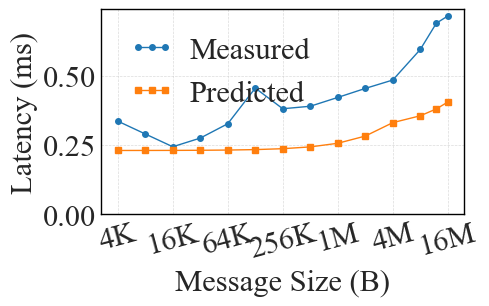

In [335]:
plot_latency_comparison(
    df=df_sweep_data_simple_tree_v1,
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='Latency (ms)',
    pdf_filename='allreduce_tree_simple_pre_comparison_v1.pdf' 
)

📄 Plot saved to: allreduce_tree_simple_BW_pre_comparison_v1.pdf


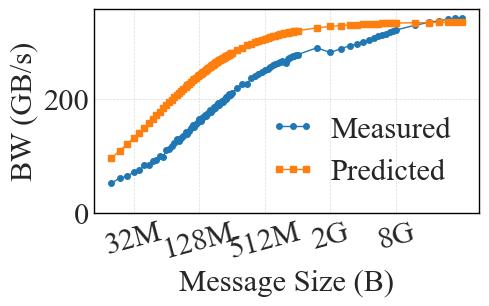

In [336]:
plot_BW_comparison(
    df=df_sweep_data_simple_tree_v1,
    y_cols=['BW (GB/s)', 'BW_pre (GB/s)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='BW (GB/s)',
    pdf_filename='allreduce_tree_simple_BW_pre_comparison_v1.pdf' 
)